<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-2-Distribution-Learning/Untitled151.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Finding the annihilator**

To illustrate how the annihilator of a distribution can be recovered from data, we consider the Heisenberg distribution
$$
{\cal D}=\operatorname{span}\{X_1,X_2\}\subset TR^3.
$$
We generate a dataset consisting of $N=1,000$ pairs $(q_i,v_i)$, where the points
$q_i\in R^3$ are sampled in a prescribed neighborhood of the origin and the velocities
$$
v_i=\alpha_i\,X_1(q_i)+\beta_i\,X_2(q_i)\in{\cal D}_{q_i}
$$
are random linear combinations of the horizontal vector fields, with coefficients
$\alpha_i,\beta_i\in R$ drawn independently.

epoch     1 | loss 9.987667e-01 | orth 9.786316e-02 | norm 9.009036e-01
epoch   100 | loss 7.370633e-02 | orth 8.468820e-03 | norm 6.523751e-02
epoch   200 | loss 5.064126e-03 | orth 2.386277e-03 | norm 2.677849e-03
epoch   300 | loss 1.720569e-03 | orth 9.000333e-04 | norm 8.205354e-04
epoch   400 | loss 9.280379e-04 | orth 5.122423e-04 | norm 4.157956e-04
epoch   500 | loss 6.304971e-04 | orth 3.406177e-04 | norm 2.898794e-04


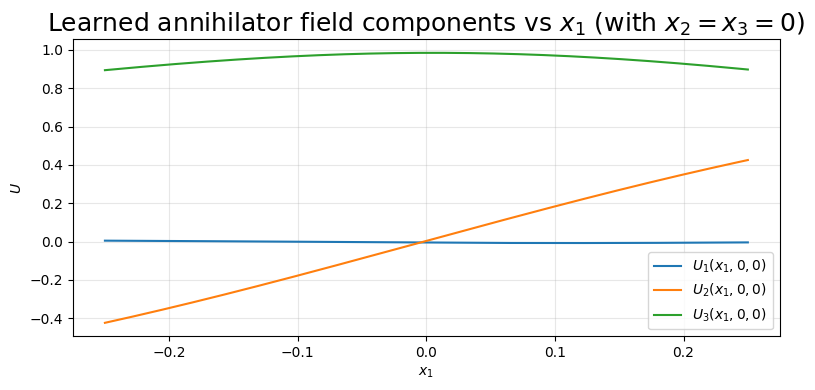

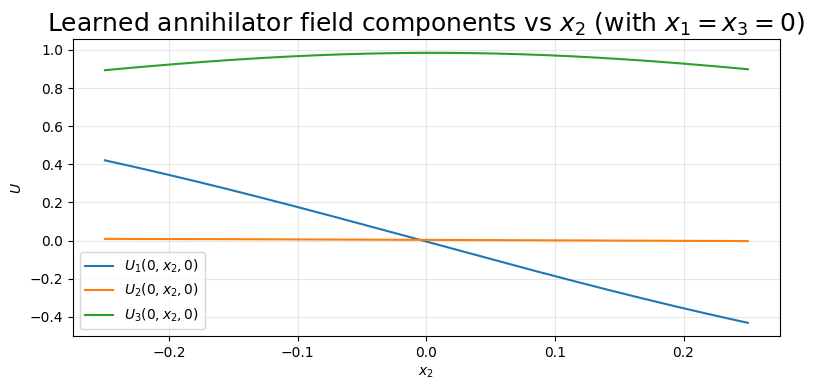

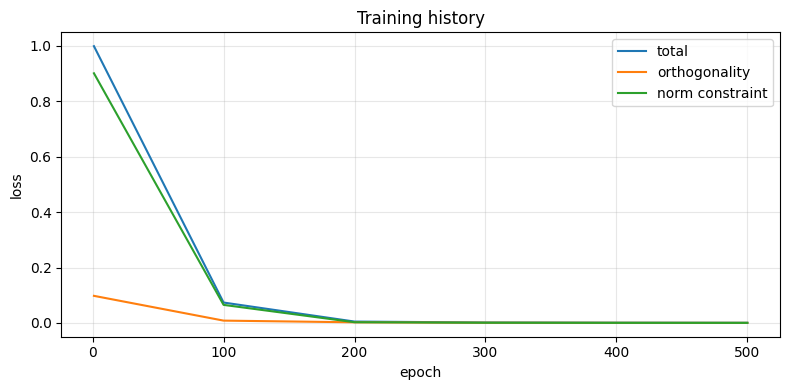

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ----------------------------
# 1) Generate synthetic data
# ----------------------------
np.random.seed(0)
tf.random.set_seed(0)

N = 1000

# sample points near origin
q = np.random.uniform(low=-1.0, high=1.0, size=(N, 3)).astype(np.float32)
x1 = q[:, 0]
x2 = q[:, 1]
x3 = q[:, 2]

# Heisenberg fields at q:
# X1(q) = (1, 0, 2 x2),  X2(q) = (0, 1, -2 x1)
X1 = np.stack([np.ones_like(x1), np.zeros_like(x2), 2.0 * x2], axis=1).astype(np.float32)
X2 = np.stack([np.zeros_like(x1), np.ones_like(x2), -2.0 * x1], axis=1).astype(np.float32)

# random coefficients
alpha = np.random.normal(size=(N, 1)).astype(np.float32)
beta  = np.random.normal(size=(N, 1)).astype(np.float32)

# horizontal velocities v_i = alpha_i X1(q_i) + beta_i X2(q_i)
v = alpha * X1 + beta * X2  # (N,3)

# convert to tensors
q_tf = tf.convert_to_tensor(q, dtype=tf.float32)
v_tf = tf.convert_to_tensor(v, dtype=tf.float32)

# ----------------------------
# 2) Model U_theta: R^3 -> R^3
# ----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(64, activation="tanh"),
    tf.keras.layers.Dense(3, activation=None),
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# ----------------------------
# 3) Loss: orthogonality + nontriviality
# ----------------------------
lam_norm = 1.0   # weight for norm constraint

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        U = model(q_tf)                              # (N,3)
        dot = tf.reduce_sum(U * v_tf, axis=1)        # (N,)
        L_orth = tf.reduce_mean(dot**2)

        # prevent trivial U=0: enforce ||U|| ~ 1 on the training points
        U_norm2 = tf.reduce_sum(U*U, axis=1)         # (N,)
        L_norm = tf.reduce_mean((U_norm2 - 1.0)**2)

        loss = L_orth + lam_norm * L_norm

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, L_orth, L_norm

# ----------------------------
# 4) Train
# ----------------------------
epochs = 500
log_every = 100
hist = {"loss": [], "orth": [], "norm": [], "ep": []}

for ep in range(1, epochs + 1):
    loss, L_orth, L_norm = train_step()
    if ep % log_every == 0 or ep == 1:
        print(f"epoch {ep:5d} | loss {loss.numpy():.6e} | orth {L_orth.numpy():.6e} | norm {L_norm.numpy():.6e}")
        hist["ep"].append(ep)
        hist["loss"].append(loss.numpy())
        hist["orth"].append(L_orth.numpy())
        hist["norm"].append(L_norm.numpy())

# ----------------------------
# 5) Plot U components vs x1 alone, and vs x2 alone
#    ("alone" = vary one coordinate, fix the others)
# ----------------------------
M = 800

# Vary x1, fix x2=0, x3=0
x1_line = np.linspace(-0.25, 0.25, M).astype(np.float32)
q_line_x1 = np.stack([x1_line, np.zeros_like(x1_line), np.zeros_like(x1_line)], axis=1)
U_x1 = model(tf.convert_to_tensor(q_line_x1)).numpy()

plt.figure(figsize=(8,4))
plt.plot(x1_line, U_x1[:,0], label=r"$U_1(x_1,0,0)$")
plt.plot(x1_line, U_x1[:,1], label=r"$U_2(x_1,0,0)$")
plt.plot(x1_line, U_x1[:,2], label=r"$U_3(x_1,0,0)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$U$")
plt.title("Learned annihilator field components vs $x_1$ (with $x_2=x_3=0$)", fontsize =18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Vary x2, fix x1=0, x3=0
x2_line = np.linspace(-0.25, 0.25, M).astype(np.float32)
q_line_x2 = np.stack([np.zeros_like(x2_line), x2_line, np.zeros_like(x2_line)], axis=1)
U_x2 = model(tf.convert_to_tensor(q_line_x2)).numpy()

plt.figure(figsize=(8,4))
plt.plot(x2_line, U_x2[:,0], label=r"$U_1(0,x_2,0)$")
plt.plot(x2_line, U_x2[:,1], label=r"$U_2(0,x_2,0)$")
plt.plot(x2_line, U_x2[:,2], label=r"$U_3(0,x_2,0)$")
plt.xlabel(r"$x_2$")
plt.ylabel(r"$U$")
plt.title("Learned annihilator field components vs $x_2$ (with $x_1=x_3=0$)",
    fontsize=18
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 6) (Optional) Training curves
# ----------------------------
plt.figure(figsize=(8,4))
plt.plot(hist["ep"], hist["loss"], label="total")
plt.plot(hist["ep"], hist["orth"], label="orthogonality")
plt.plot(hist["ep"], hist["norm"], label="norm constraint")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training history")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
